In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np

# How do the pool of RPTR BCs grow?

## Chop TFs

In [2]:
chopTFs = pd.read_csv("../../output/ChopTFs_pipeline/time_normalization/DBD_time_normalized_activities.csv")
chopTFs

,Unnamed: 0,AD,AD_end,AD_BC,RPTR_BC,count_simple_AD,count_directional_AD,rep,time,count_simple_RT,...,activity_simple,activity_directional,ADseq,dbd_overlap_flag,mu,sigma,z-scored_activity,shifted_activity,shifted_active,z-score_active
0,0,AAAAATTCATTCTCTTTGGCTAAATCTGAAGAATCTACTAATGATT...,TTCTGAGAATCCATTGAATGAAGCTCAACAACAAGATCAA,ATAACCAATGG,TGAGAGAAAATCTA,177.0,175.0,2,0,11.0,...,-1.206581,-1.201645,KNSFSLAKSEESTNDYAMANYLNNTPISENPLNEAQQQDQ,False,-1.051051,0.307293,-0.490068,-0.150595,False,False
1,1,AAAAATTCATTCTCTTTGGCTAAATCTGAAGAATCTACTAATGATT...,TTCTGAGAATCCATTGAATGAAGCTCAACAACAAGATCAA,TATCTTCGCTT,CCCTCACCCGATTA,24.0,24.0,2,0,2.0,...,-1.079181,-1.380211,KNSFSLAKSEESTNDYAMANYLNNTPISENPLNEAQQQDQ,False,-1.051051,0.307293,-1.071161,-0.329160,False,False
2,2,AAAAATTCTAAGAGACAGAAATCTTCTACTTATACTTCTCAAACTT...,AATCTTGTCTAATTTGGCTTCATTCTATAATACTCATGGT,AATCGTACCGA,TTTGATATCCAAAC,29.0,28.0,2,0,1.0,...,-1.462398,-1.447158,KNSKRQKSSTYTSQTSSPIGPRDPTVQILSNLASFYNTHG,False,-1.051051,0.307293,-1.289021,-0.396107,False,False
3,3,AAAAATTCTAAGAGACAGAAATCTTCTACTTATACTTCTCAAACTT...,AATCTTGTCTAATTTGGCTTCATTCTATAATACTCATGGT,TTGCATAGCTG,TATTGTTCTCTGCT,63.0,63.0,2,0,1.0,...,-1.799341,-1.799341,KNSKRQKSSTYTSQTSSPIGPRDPTVQILSNLASFYNTHG,False,-1.051051,0.307293,-2.435102,-0.748290,False,False
4,4,AAAAATTCTAAGAGACAGAAATCTTCTACTTATACTTCTCAAACTT...,AATCTTGTCTAATTTGGCTTCATTCTATAATACTCATGGT,TTTATAATACC,CATCGAACCTGAAC,122.0,120.0,2,0,11.0,...,-1.044967,-1.124939,KNSKRQKSSTYTSQTSSPIGPRDPTVQILSNLASFYNTHG,False,-1.051051,0.307293,-0.240448,-0.073888,False,False
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1361924,1361924,TTTGTTTCTTTGTTGGATACTCCATCTAAGAAATCTGATTCTAAAT...,ACATCCTAAAGTTTCTAATATGTCTGGATTCTTGGCTGGT,CCAAACTTGGA,CAATTGACACTACG,55.0,53.0,4,60,5.0,...,-1.041393,-1.122216,FVSLLDTPSKKSDSKSGGSSFMLGNWKHPKVSNMSGFLAG,False,-0.746292,0.402798,-0.933281,-0.375924,False,False
1361925,1361925,TTTGTTTCTTTGTTGGATACTCCATCTAAGAAATCTGATTCTAAAT...,ACATCCTAAAGTTTCTAATATGTCTGGATTCTTGGCTGGT,CCCACTCTCAG,CGCACGAATACCCG,18.0,18.0,4,60,2.0,...,-0.954243,-0.954243,FVSLLDTPSKKSDSKSGGSSFMLGNWKHPKVSNMSGFLAG,False,-0.746292,0.402798,-0.516265,-0.207950,False,False
1361926,1361926,TTTGTTTCTTTGTTGGATACTCCATCTAAGAAATCTGATTCTAAAT...,ACATCCTAAAGTTTCTAATATGTCTGGATTCTTGGCTGGT,GGGTCGTAAAT,CAACAGCCCTTACG,8.0,8.0,4,60,4.0,...,-0.301030,-0.425969,FVSLLDTPSKKSDSKSGGSSFMLGNWKHPKVSNMSGFLAG,False,-0.746292,0.402798,0.795246,0.320323,False,False
1361927,1361927,TTTGTTTGTGATTATTGTGGTAAGAGATTTACTCAAGGTGGTAATT...,ACCATATTCTTGTGATATTTGTGATAAGAAATTCTCTAGA,GATCCCATGCA,CTCTGCTACTTGTG,126.0,124.0,4,60,56.0,...,-0.352183,-0.421324,FVCDYCGKRFTQGGNLRTHERLHTGEKPYSCDICDKKFSR,False,-0.746292,0.402798,0.806778,0.324968,False,False


In [57]:
chopTFs_RTBC_count = pd.DataFrame(chopTFs.groupby(["rep", "time"])["count_directional_RT"].sum()).reset_index()
chopTFs_ADBC_count = pd.DataFrame(chopTFs.groupby(["rep", "time"])["count_directional_AD"].sum()).reset_index()

## GCN4

In [29]:
gcn4 = pd.read_csv("../../output/GCN4_pipeline/time_normalization/DBD_time_normalized_activities.csv")
gcn4

,Unnamed: 0,AD,AD_BC,RPTR_BC,rep,time,count_simple_AD,count_directional_AD,count_simple_RT,count_directional_RT,activity_simple,activity_directional,ADseq,dbd_overlap_flag,mu,sigma,z-scored_activity,shifted_activity,shifted_active,z-score_active
0,0,GCTGCTGTTGATTTGAACTTTGAAGCTGCTATTCCATCTTCTAGAG...,GCATATAGAGA,CCTGCTATTCGTAA,1,10,106,98,80,51,-0.281412,-0.653142,AAVDLNFEAAIPSSRARSHTAATIPPLDFSVFTTDSLQQS,False,-2.451464,0.596621,3.014179,1.798322,False,True
1,1,TCTAATACTCAAGCTGTTACTGGTCAACATAGAAGACATTCTTCTA...,CCACAGACGGA,TACCTCCGACTGTC,1,10,106,103,6,5,-2.871680,-3.025291,SNTQAVTGQHRRHSSNLPSASSLQNQRVAAIIQSTGHSIS,False,-2.451464,0.596621,-0.961795,-0.573827,False,False
2,2,GCTGAAATTAGAGGTGGTACTAGATTGGTTTGTAGAAGAGAGAATG...,CAGACCAAGAA,GTGGTCAAGGCTCG,1,10,106,103,12,8,-2.178532,-2.555287,AEIRGGTRLVCRRENGHQVLQGVSHPPWRSKRSSPPDTPL,False,-2.451464,0.596621,-0.174019,-0.103823,False,False
3,3,GAAGTTGGTGACTTCTCTGTTAATAAACCACCACAAGCTGATGATA...,ATTTGTACTAG,CCATGTTTGGCGAA,1,10,106,102,7,6,-2.717529,-2.833213,EVGDFSVNKPPQADDMVMSSRQEKGKQPDVATWDAHSNKG,False,-2.451464,0.596621,-0.639852,-0.381749,False,False
4,4,TTGGCTTCTCCACATTTGTTGTTGGTTAATGTTCATTGTCATGAAC...,AACGTTCCTCA,ATATAAAGCGATTG,1,10,106,100,10,8,-2.360854,-2.525729,LASPHLLLVNVHCHEPMLSLLYTTDQVQNSGSLLPVSSTP,False,-2.451464,0.596621,-0.124475,-0.074264,False,False
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
342856,342856,TTGGGTCCAACTGTTTCTCCTAAAGATATCTTTAATATTGATTCTG...,CCCCCTCACGC,CCCTGCCCCGTTAG,1,15,2,2,2,1,0.000000,-0.693147,LGPTVSPKDIFNIDSVPPSTSLTNLTTPGSTYLDTPDDSF,False,-2.226869,0.783576,1.957336,1.533722,False,False
342857,342857,TCTGGTTCTACTAGAACTGTTTCTCCTAAAGATATCTTTGCTGATG...,AATTGAGCAAA,TTCTTCGTACCTAA,1,15,2,2,209,129,4.649187,4.166665,SGSTRTVSPKDIFADAFGSAPPSAAFTNLTSPDIDASPFL,False,-2.226869,0.783576,8.159430,6.393534,True,True
342858,342858,CAACAAACTCCATCTGTTGCTAAGATGTCTATTGCTGAATTGGATG...,GAAGAATCTGA,TCTACAGATAAGTT,1,15,1,1,6,2,1.791759,0.693147,QQTPSVAKMSIAELDDFTGFEGGASTAYSSPGAPAVFDVP,False,-2.226869,0.783576,3.726526,2.920016,True,True
342859,342859,AGATTTAATTCTATTGCTCAGAATCAATCTCAACATCAACAATTCT...,AGAATCAGTAA,TGAGAGCGAGGCGA,1,15,1,1,3,2,1.098612,0.693147,RFNSIAQNQSQHQQFYAPLSTSSSAAVVNQQTRIARPPIP,False,-2.226869,0.783576,3.726526,2.920016,True,True


In [58]:
gcn4_RTBC_count = pd.DataFrame(gcn4.groupby(["rep", "time"])["count_directional_RT"].sum()).reset_index()
gcn4_ADBC_count = pd.DataFrame(gcn4.groupby(["rep", "time"])["count_directional_AD"].sum()).reset_index()


## Both together

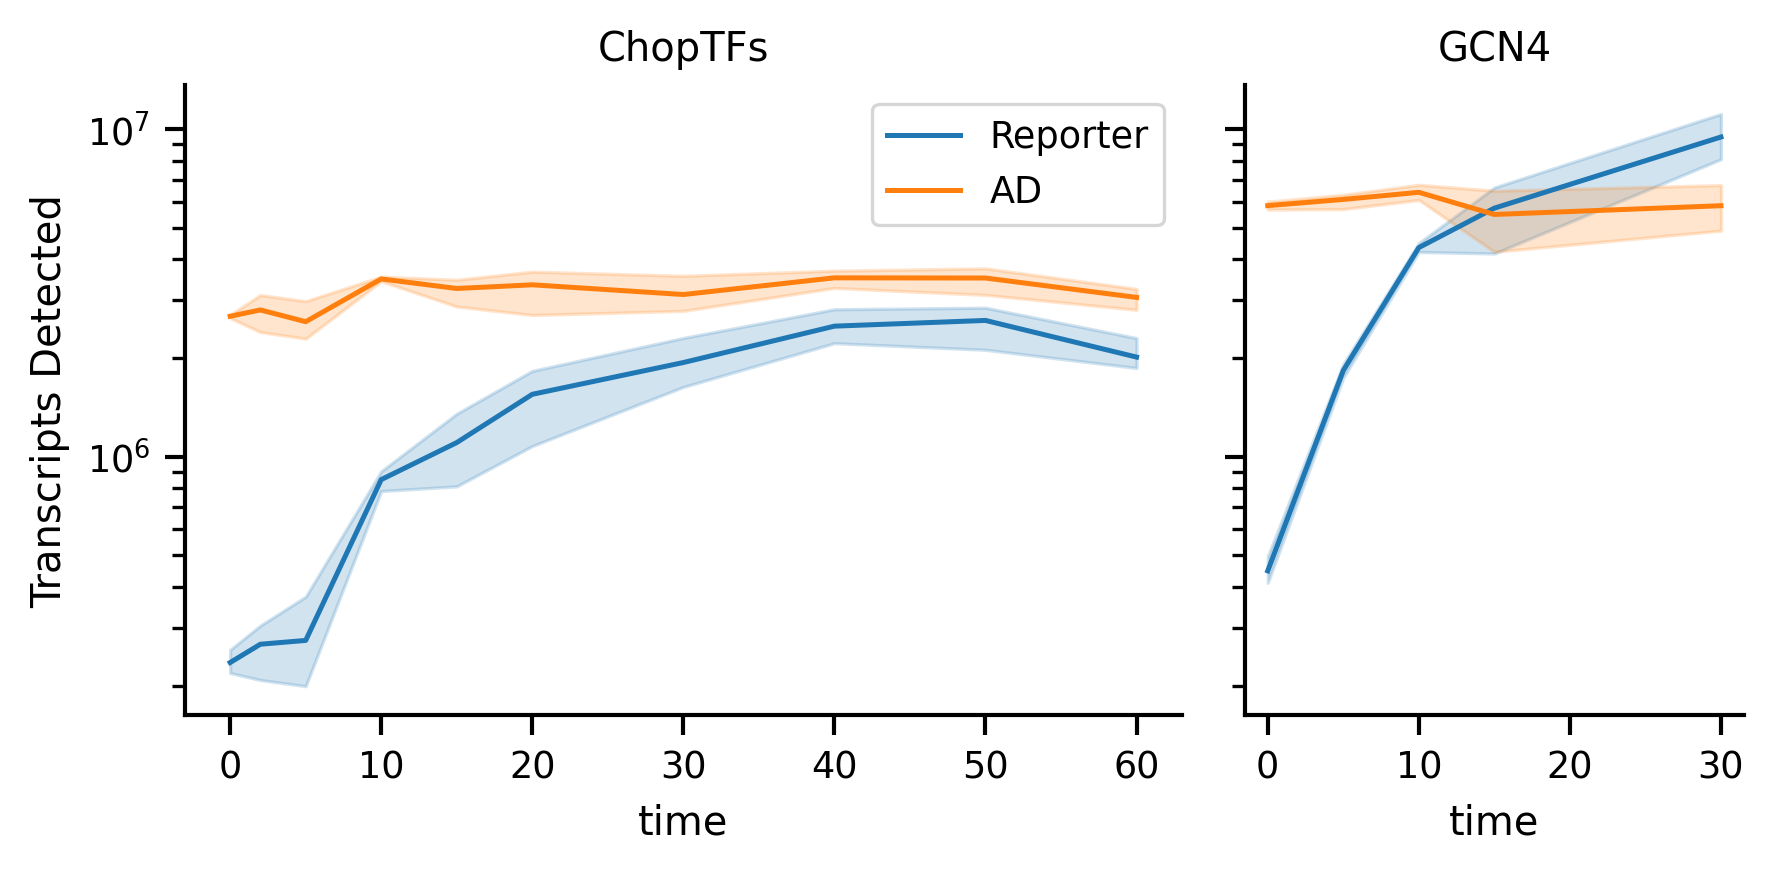

In [88]:
sns.set_context('paper')
fig, axes = plt.subplots(1, 2, figsize=(6,3), dpi=300,
                         gridspec_kw={"width_ratios": [2, 1]}, sharey = True)

sns.lineplot(data=chopTFs_RTBC_count, x="time", y="count_directional_RT", ax=axes[0], label = "Reporter")
sns.lineplot(data=chopTFs_ADBC_count, x="time", y="count_directional_AD", ax=axes[0], label = "AD")
axes[0].set_ylabel("Transcripts Detected")
# axes[0].set_ylim(0, None)
axes[0].set_title("ChopTFs")

sns.lineplot(data=gcn4_RTBC_count[gcn4_RTBC_count["time"] < 31], x="time", y="count_directional_RT", ax=axes[1])
sns.lineplot(data=gcn4_ADBC_count[gcn4_ADBC_count["time"] < 31], x="time", y="count_directional_AD", ax=axes[1])
# axes[1].set_ylim(0, None)
axes[1].set_title("GCN4")
axes[1].set_ylabel("")

axes[0].set_yscale('log')

sns.despine()
plt.tight_layout()
plt.show()

# Preseq total pool size estimate

In [68]:
AD_chop_est = pd.read_csv("../../output/ChopTFs_pipeline/AD_transcript_size_estimate.csv", index_col = 0)
AD_chop_est.head()

,pop_size_estimate,lower_ci,upper_ci,rep,time
0,14964822.7,9764701.5,71166240.8,2,0
1,12762225.4,10284359.2,47846261.3,2,2
2,11974449.7,9105665.9,53422837.1,2,5
3,14803914.2,12744876.4,31934351.5,2,10
4,15854568.9,13080607.3,58595116.3,2,15


In [69]:
RT_chop_est = pd.read_csv("../../output/ChopTFs_pipeline/RT_transcript_size_estimate.csv", index_col = 0)
RT_chop_est.head()

,index,pop_size_estimate,lower_ci,upper_ci,rep,time
0,0,781147.3,680018.3,1420123.8,2,0
4,0,2405276.8,1421112.7,18034017.6,2,2
8,0,2521074.8,1647959.1,10049077.3,2,5
1,0,5229649.3,4433776.2,18000871.4,2,10
2,0,6952746.0,5292740.9,28245392.5,2,15


In [77]:
AD_gcn4_est = pd.read_csv("../../output/GCN4_preseq_AD.csv")
AD_gcn4_est.head()

,Unnamed: 0,pop_size_estimate,lower_ci,upper_ci,rep,time
0,0,13856276.5,10253555.5,15598917.1,1,0
1,1,14458222.2,10768754.2,16345091.7,1,5
2,2,14739967.9,12152555.2,19026489.8,1,10
3,3,11722134.3,9418236.1,13105713.7,1,15
4,4,14041660.8,11365888.7,16909085.5,1,30


In [78]:
RT_gcn4_est = pd.read_csv("../../output/GCN4_preseq_RT.csv")
RT_gcn4_est.head()

,Unnamed: 0,pop_size_estimate,lower_ci,upper_ci,converged,rep,time
0,0,141147872.7,65567933.4,2.068118e+09,not_converged,1,0
1,6,188217015.1,132109995.7,6.473644e+08,not_converged,1,5
2,1,410399668.5,318340893.3,2.067977e+09,not_converged,1,10
3,2,361155110.7,294169353.8,6.850845e+08,not_converged,1,15
4,5,555041009.6,454734221.6,3.100442e+09,not_converged,1,30


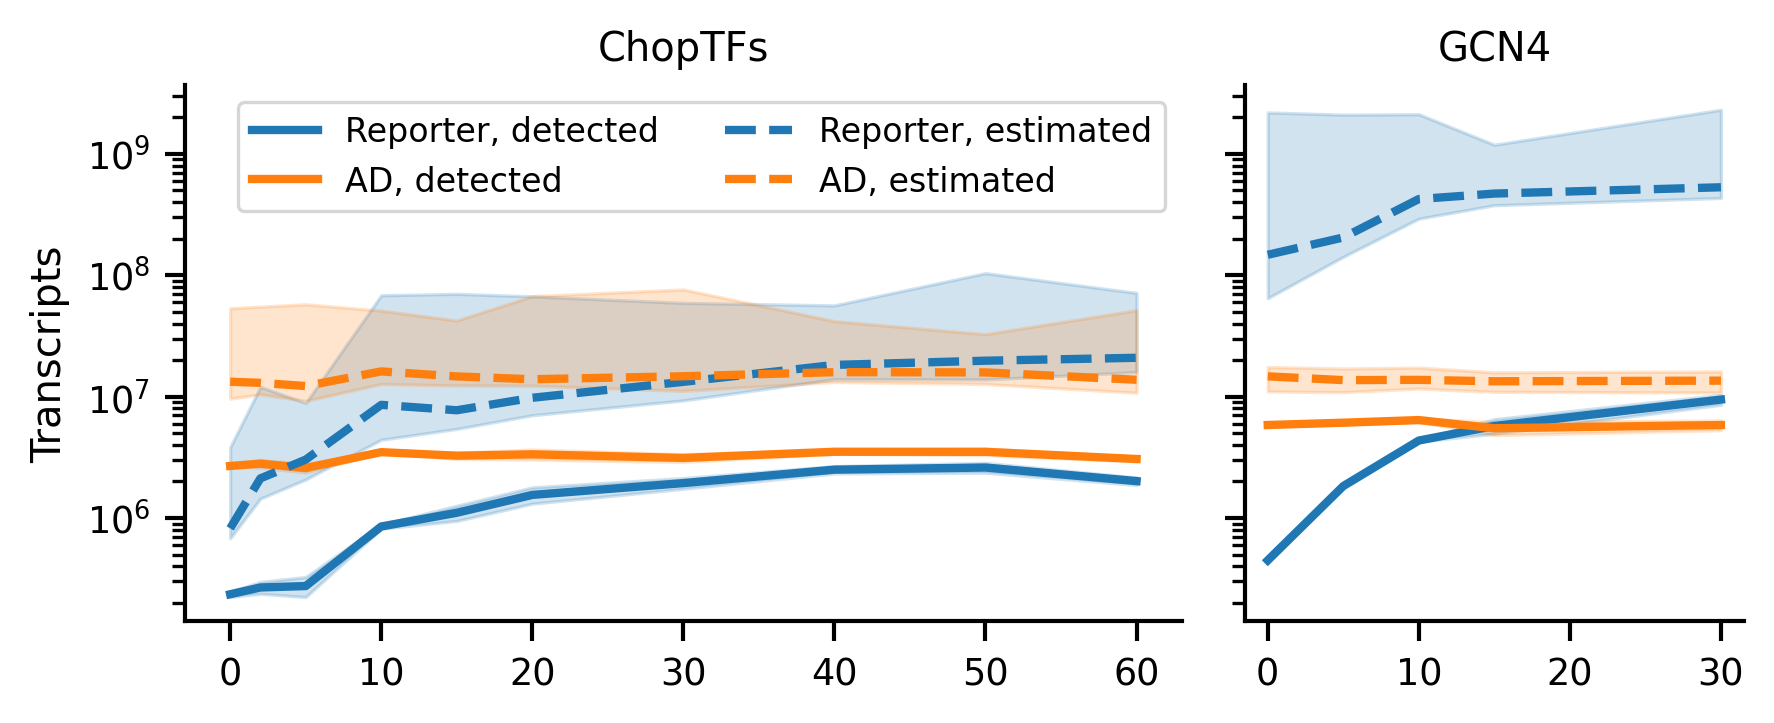

In [106]:
sns.set_context('paper')

fig, axes = plt.subplots(1, 2, figsize=(6,2.5), dpi=300,
                         gridspec_kw={"width_ratios": [2, 1]}, sharey=True)

def plot_panel(ax, rt_obs, ad_obs, rt_est, ad_est, title, time_filter=None):
    if time_filter:
        rt_obs = rt_obs[rt_obs["time"] < time_filter]
        ad_obs = ad_obs[ad_obs["time"] < time_filter]
        rt_est = rt_est[rt_est["time"] < time_filter]
        ad_est = ad_est[ad_est["time"] < time_filter]

    # --- observed: mean across reps ---
    
    rt_obs_grp = rt_obs.groupby("time")["count_directional_RT"].agg(["mean", "std", "count"])
    ad_obs_grp = ad_obs.groupby("time")["count_directional_AD"].agg(["mean", "std", "count"])
    
    # SE = SD / sqrt(n)
    rt_obs_grp["se"] = rt_obs_grp["std"] / rt_obs_grp["count"].pow(0.5)
    ad_obs_grp["se"] = ad_obs_grp["std"] / ad_obs_grp["count"].pow(0.5)
    
    ax.plot(rt_obs_grp.index, rt_obs_grp["mean"], color="C0", lw=2, label="Reporter, detected")
    ax.fill_between(rt_obs_grp.index,
                    rt_obs_grp["mean"] - rt_obs_grp["se"],
                    rt_obs_grp["mean"] + rt_obs_grp["se"],
                    color="C0", alpha=0.2)
    
    ax.plot(ad_obs_grp.index, ad_obs_grp["mean"], color="C1", lw=2, label="AD, detected")
    ax.fill_between(ad_obs_grp.index,
                    ad_obs_grp["mean"] - ad_obs_grp["se"],
                    ad_obs_grp["mean"] + ad_obs_grp["se"],
                    color="C1", alpha=0.2)

    # --- estimated: mean + CI across reps ---
    rt_grp = rt_est.groupby("time").agg(
        mean=("pop_size_estimate", "mean"),
        lo=("lower_ci", "mean"),
        hi=("upper_ci", "mean")
    )
    ad_grp = ad_est.groupby("time").agg(
        mean=("pop_size_estimate", "mean"),
        lo=("lower_ci", "mean"),
        hi=("upper_ci", "mean")
    )
    ax.plot(rt_grp.index, rt_grp["mean"], color="C0", lw=2, linestyle="--", label="Reporter, estimated")
    ax.fill_between(rt_grp.index, rt_grp["lo"], rt_grp["hi"], color="C0", alpha=0.2)
    ax.plot(ad_grp.index, ad_grp["mean"], color="C1", lw=2, linestyle="--", label="AD, estimated")
    ax.fill_between(ad_grp.index, ad_grp["lo"], ad_grp["hi"], color="C1", alpha=0.2)

    ax.set_yscale("log")
    ax.set_title(title)

plot_panel(axes[0], chopTFs_RTBC_count, chopTFs_ADBC_count,
           RT_chop_est, AD_chop_est, "ChopTFs")
plot_panel(axes[1], gcn4_RTBC_count, gcn4_ADBC_count,
           RT_gcn4_est, AD_gcn4_est, "GCN4", time_filter=31)

axes[0].set_ylabel("Transcripts")
axes[0].legend(fontsize='small',ncols = 2)
axes[1].set_ylabel("")

sns.despine()
plt.tight_layout()
plt.savefig("../../output/paper_figs/SX_obs_vs_est_transcripts.png", bbox_inches = 'tight')
plt.savefig("../../output/paper_figs/SX_obs_vs_est_transcripts.pdf", bbox_inches = 'tight')
plt.show()

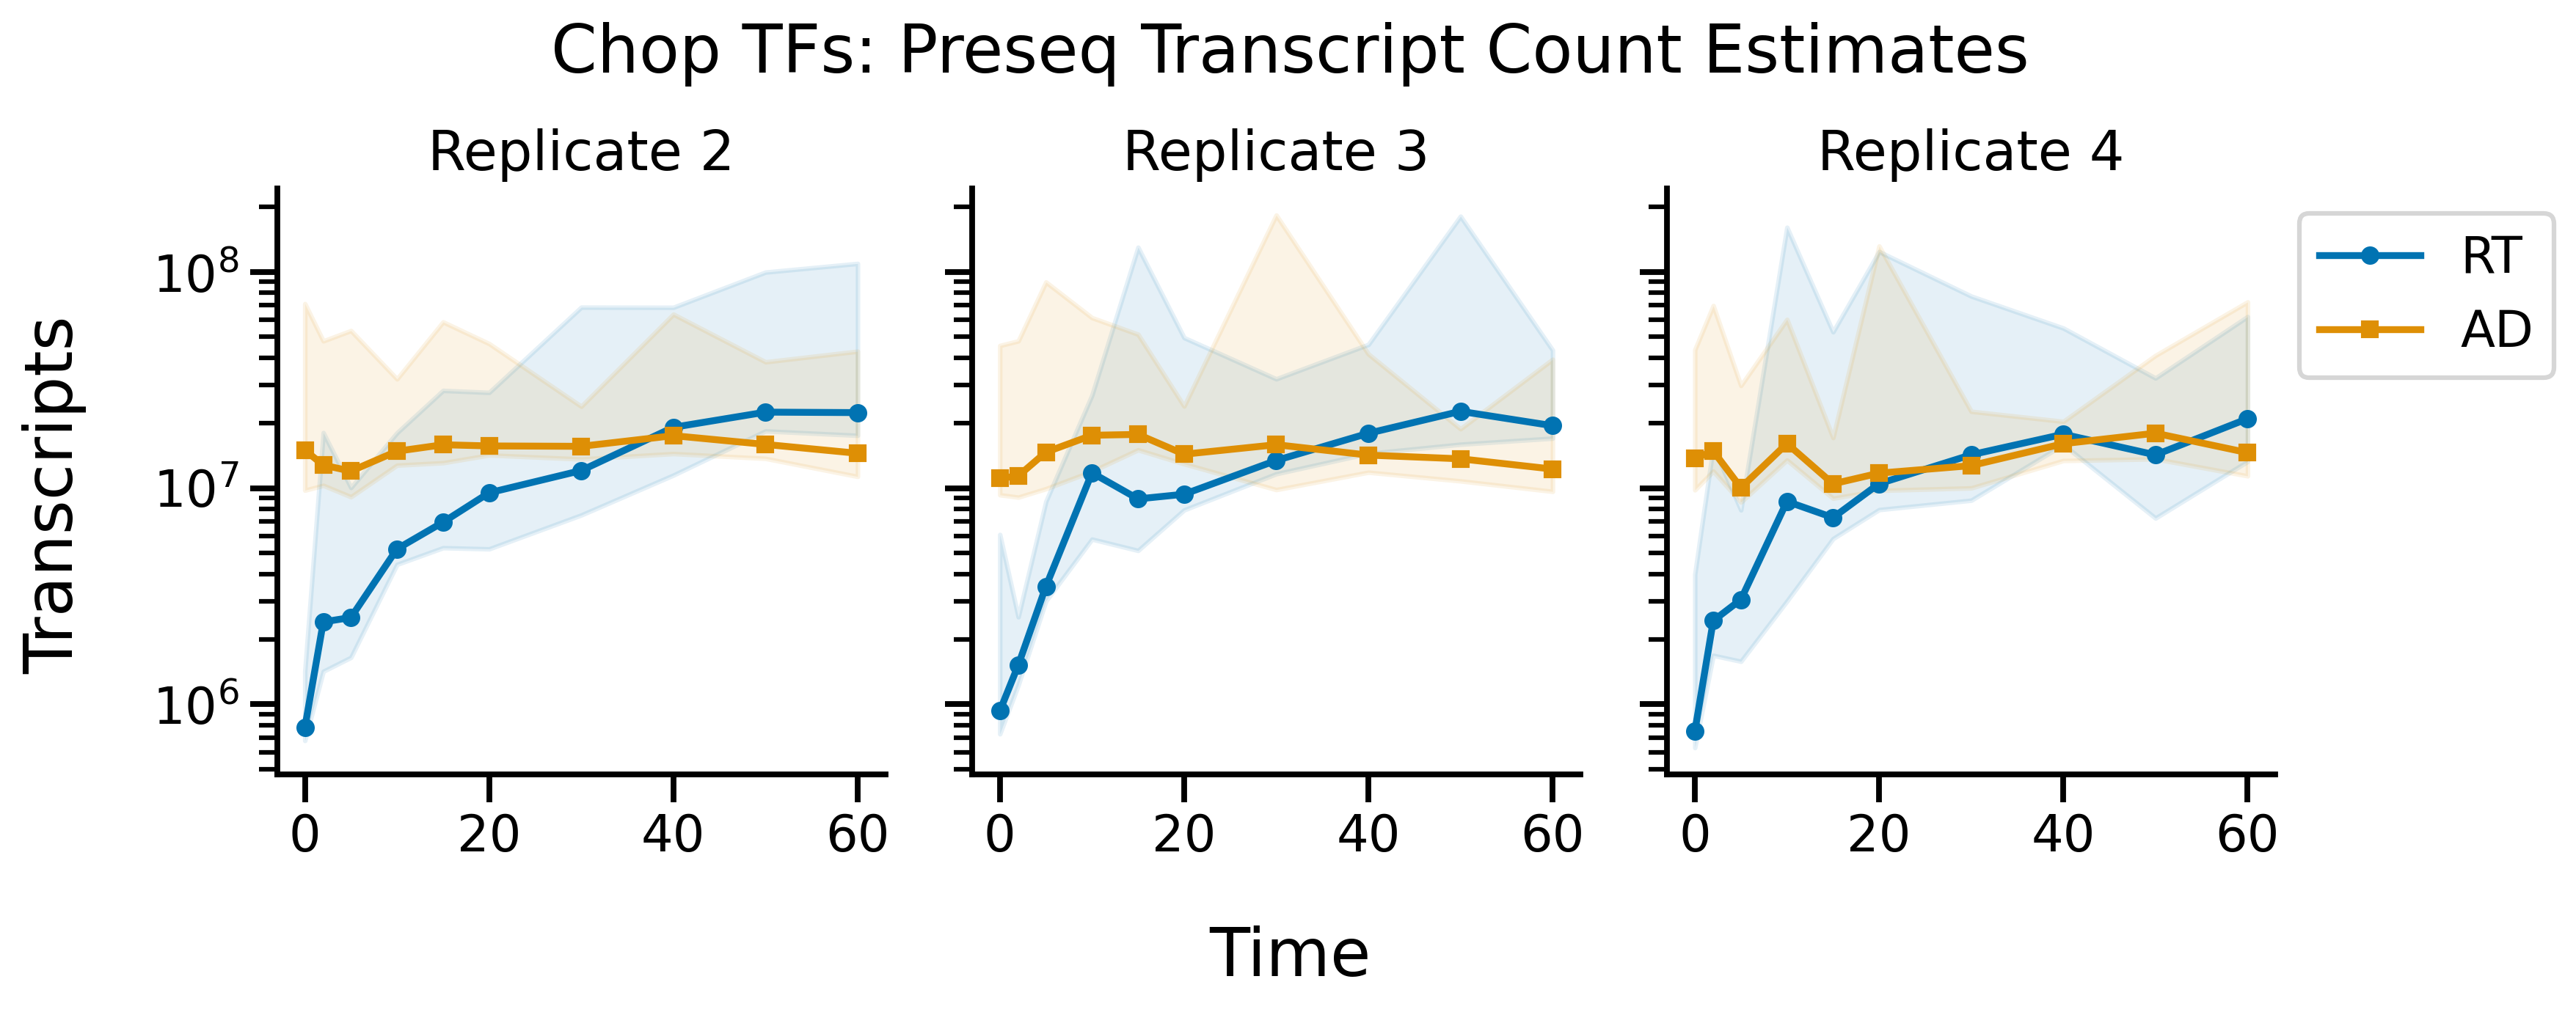

In [71]:
sns.set_context("talk")
palette = sns.color_palette("colorblind")

n_reps = 3
eps = 0  # pseudocount to avoid log(0)

fig, axes = plt.subplots(
    1, n_reps, figsize=(4 * n_reps, 5), sharex=True, sharey=True, dpi=300
)

if n_reps == 1:
    axes = [axes]

for ax, rep in zip(axes, range(2, n_reps + 2)):
    # RT
    g_rt = RT_chop_est[RT_chop_est["rep"] == rep].sort_values("time")
    ax.plot(
        g_rt["time"],
        g_rt["pop_size_estimate"] + eps,
        color=palette[0],
        marker="o",
        markersize=5,
        label="RT"
    )
    ax.fill_between(
        g_rt["time"],
        g_rt["lower_ci"] + eps,
        g_rt["upper_ci"] + eps,
        color=palette[0],
        alpha=0.1
    )

    # AD
    g_ad = AD_chop_est[AD_chop_est["rep"] == rep].sort_values("time")
    ax.plot(
        g_ad["time"],
        g_ad["pop_size_estimate"] + eps,
        color=palette[1],
        marker="s",
        markersize=5,
        label="AD"
    )
    ax.fill_between(
        g_ad["time"],
        g_ad["lower_ci"] + eps,
        g_ad["upper_ci"] + eps,
        color=palette[1],
        alpha=0.1
    )

    ax.set_yscale("log")
    ax.set_title(f"Replicate {rep}")

# Global labels
fig.supxlabel("Time", y=0.05)
fig.supylabel("Transcripts", x=0.02)
fig.suptitle("Chop TFs: Preseq Transcript Count Estimates", y=0.93)

# Legend (only once)
axes[2].legend(loc="upper right",bbox_to_anchor = (1.5,1))

plt.tight_layout()
sns.despine()
plt.show()